<a href="https://colab.research.google.com/github/Kamindumenula/SE4050-Household-Waste-Classification-System/blob/main/cnn/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


#DOWNLOAD & EXTRACT DATASET

if not os.path.exists("SE4050-Household-Waste-Classification-System"):
    !git clone https://github.com/Kamindumenula/SE4050-Household-Waste-Classification-System.git

DATASET_DIR = "/content/dataset-resized"
if not os.path.exists(DATASET_DIR):
    !unzip -q -o SE4050-Household-Waste-Classification-System/dataset/archive.zip -d /content/


# LOAD & SPLIT (80% TRAIN, 10% VAL, 10% TEST)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load 80% for training
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load 20% held-out
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split the 20% into 10% val and 10% test
val_size = int(len(val_test_ds) * 0.5)
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

# APPLY COMMON DATA AUGMENTATION (ONLY TO TRAIN DATASET!)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),  # Flips left/right
    layers.RandomRotation(0.15),      # Rotates ±15%
    layers.RandomZoom(0.15),          # Zooms in/out ±15%
    layers.RandomContrast(0.1),       # Slight lighting change
], name="common_data_augmentation")

# apply augmentation directly to train_ds:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


# SPEED OPTIMIZATION (CACHE & PREFETCH)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

classes = sorted(os.listdir(DATASET_DIR))
print(f"Setup Complete!")
print(f"Classes ({len(classes)}): {classes}")
print(f"Batches -> Train: {len(train_ds)} (Augmented) | Val: {len(val_ds)} | Test: {len(test_ds)}")

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Setup Complete!
Classes (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Batches -> Train: 64 (Augmented) | Val: 8 | Test: 8


Dataset Breakdown:
  • cardboard   : 403 images (15.9%)
  • glass       : 501 images (19.8%)
  • metal       : 410 images (16.2%)
  • paper       : 594 images (23.5%)
  • plastic     : 482 images (19.1%)
  • trash       : 137 images (5.4%)
  Total Images  : 2527


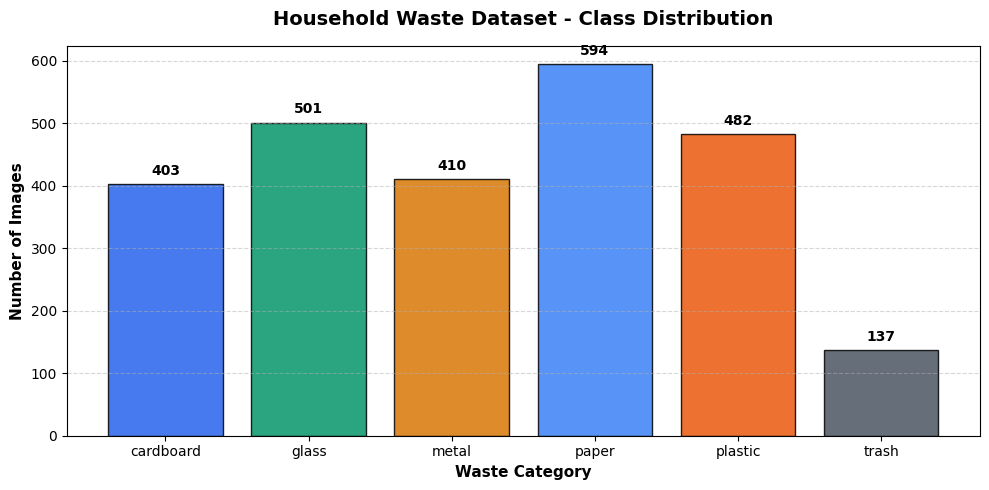

In [3]:
# EXPLORATORY DATA ANALYSIS (EDA) - CLASS DISTRIBUTION
import matplotlib.pyplot as plt
import seaborn as sns
import glob
# Count images in each category
class_names = sorted(os.listdir(DATASET_DIR))
class_counts = {c: len(glob.glob(f"{DATASET_DIR}/{c}/*.*")) for c in class_names}
print("Dataset Breakdown:")
for c, count in class_counts.items():
    print(f"  • {c:12s}: {count} images ({count/sum(class_counts.values())*100:.1f}%)")
print(f"  Total Images  : {sum(class_counts.values())}")
# Plot publication-grade bar chart for your report
plt.figure(figsize=(10, 5))
colors = ['#2563EB', '#059669', '#D97706', '#3B82F6', '#EA580C', '#4B5563']
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', alpha=0.85)
plt.title("Household Waste Dataset - Class Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Waste Category", fontsize=11, fontweight='bold')
plt.ylabel("Number of Images", fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Add exact count on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f"{yval}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=300)
plt.show()

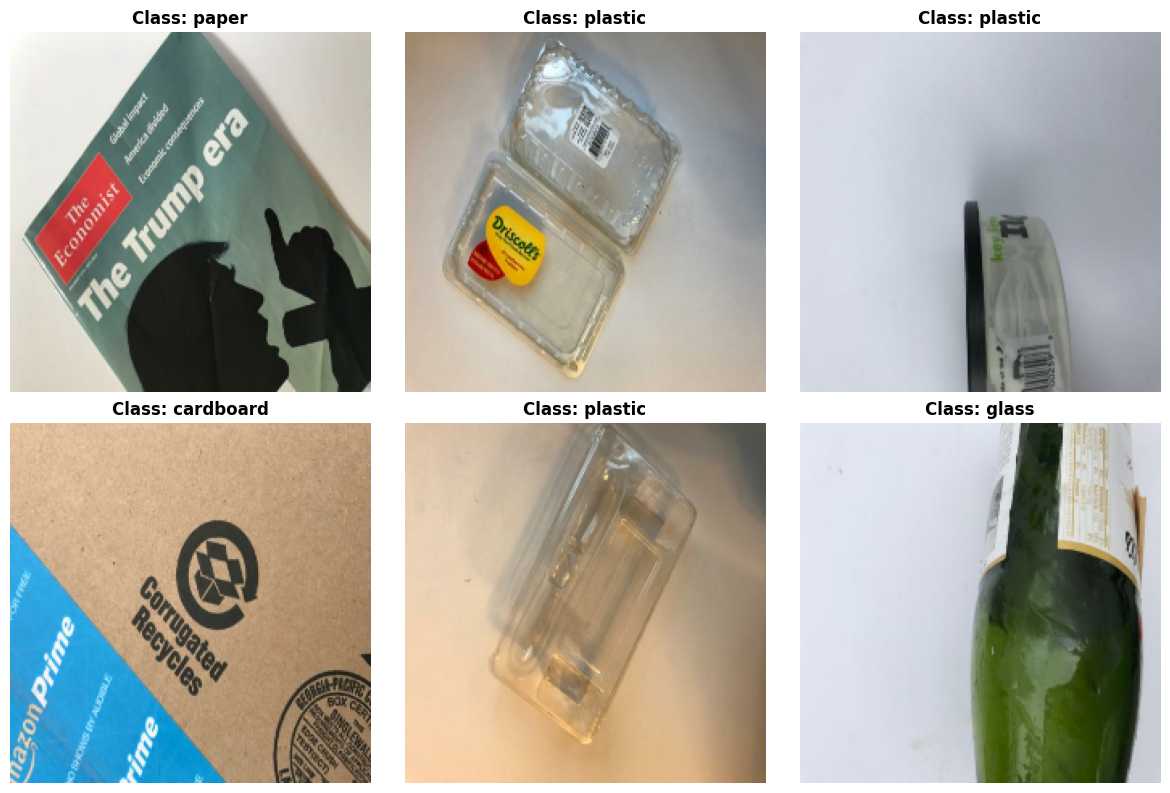

In [4]:
# VISUALIZE SAMPLE WASTE IMAGES
import numpy as np

# Grab 1 batch from the unaugmented test set to preview real images
plt.figure(figsize=(12, 8))
for images, labels in test_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Class: {class_names[labels[i]]}", fontsize=12, fontweight='bold')
        plt.axis("off")

plt.tight_layout()
plt.savefig("sample_waste_images.png", dpi=300)
plt.show()


In [5]:

# CUSTOM CNN ARCHITECTURE (MEMBER 1 BASELINE)
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # Pixel normalization (scales 0-255 RGB to 0.0-1.0)
    x = layers.Rescaling(1./255)(inputs)

    # Block 1 (Feature extraction: low-level edges)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 2 (Medium-level textures and shapes)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 3 (High-level waste part structures)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 4 (Complex semantic representations)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Classification Dense Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)  # Strong regularization against overfitting
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="Custom_Baseline_CNN")

cnn_model = build_custom_cnn()
cnn_model.summary()


Model: "Custom_Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
# COMPILE MODEL & SETUP TRAINING CALLBACKS
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list = [
    # Stops training automatically if validation loss stops improving for 8 epochs
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    # Halves the learning rate if validation loss plateaus for 3 epochs
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    # Saves best model
    keras.callbacks.ModelCheckpoint('baseline_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]


In [ ]:
# TRAIN MODEL
EPOCHS = 35

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)


Epoch 1/35
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4255 - loss: 1.5480
Epoch 1: val_accuracy improved from None to 0.08203, saving model to baseline_cnn.keras

Epoch 1: finished saving model to baseline_cnn.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 263s 4s/step - accuracy: 0.4951 - loss: 1.3518 - val_accuracy: 0.0820 - val_loss: 2.0171 - learning_rate: 0.0010
Epoch 2/35
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5561 - loss: 1.1641
Epoch 2: val_accuracy improved from 0.08203 to 0.19141, saving model to baseline_cnn.keras

Epoch 2: finished saving model to baseline_cnn.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.5702 - loss: 1.1375 - val_accuracy: 0.1914 - val_loss: 2.2885 - learning_rate: 0.0010
Epoch 3/35
 6/64 ━━━━━━━━━━━━━━━━━━━━ 3:37 4s/step - accuracy: 0.6429 - loss: 1.1723